In [1]:
import anndata as ad
import scanpy as sc
from matplotlib import rcParams
#import squidpy as sq
#import harmonypy as hm
import pandas as pd
#import scanorama
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import numpy as np

def rotate_points(spatial, theta):
    # Define the rotation matrix
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    
    # Rotate the points
    rotated_points = spatial @ rotation_matrix.T
    
    return rotated_points

# Example usage
# Create a set of points (for example)
spatial = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# Define the rotation angle (in radians)
theta = np.pi / 4  # 45 degrees

# Rotate the points
rotated_spatial = rotate_points(spatial, theta)
print(rotated_spatial)

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


In [79]:
adata_full_corr = sc.read_h5ad("/Users/manjjj/Downloads/p56_raw.h5ad")

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


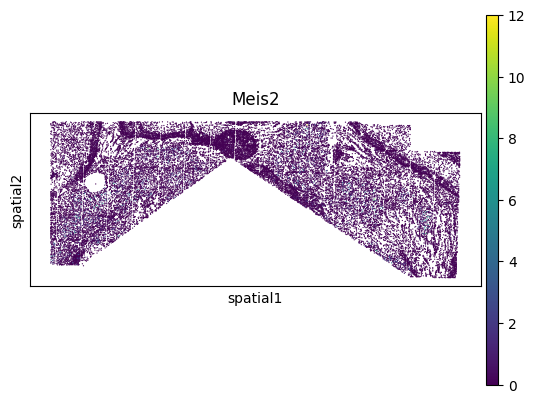

In [80]:
sc.pl.spatial(adata_full_corr, spot_size = 100, color = "Meis2")

In [81]:
sc.pp.calculate_qc_metrics(
    adata_full_corr,percent_top=None, log1p=False, inplace=True
)
sc.pp.calculate_qc_metrics(
    adata_full_corr,percent_top=None, log1p=False, inplace=True
)
sc.pp.filter_cells(adata_full_corr, min_counts=10)
sc.pp.filter_cells(adata_full_corr, max_counts=300)

sc.pp.filter_genes(adata_full_corr, min_cells=10)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


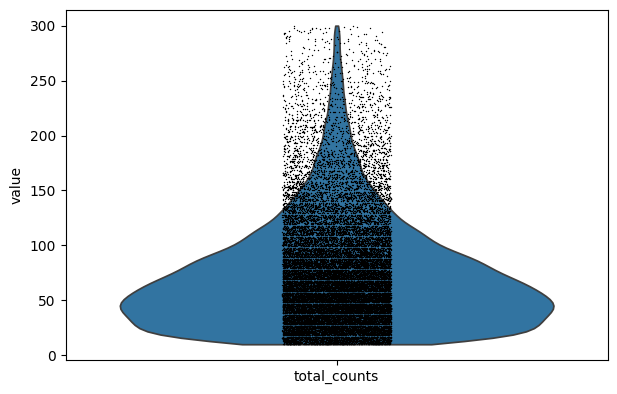

In [82]:
sc.pl.violin(adata_full_corr, keys=["total_counts"])

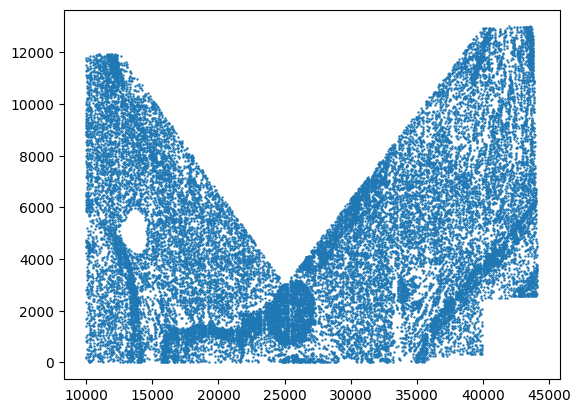

In [112]:
plt.scatter(adata_full_corr.obsm['spatial'][:,0], adata_full_corr.obsm['spatial'][:,1], s=0.5)

In [83]:
import scanpy as sc
import squidpy as sq
import scipy.sparse as sp

# --- Load your spatial AnnData ---
# Replace with your own dataset
#adata = sq.datasets.visium_hne_adata()

# --- Preprocessing ---
#sc.pp.calculate_qc_metrics(adata_full_corr, inplace=True)
sc.pp.normalize_total(adata_full_corr)
#sc.pp.log1p(adata)
#sc.pp.highly_variable_genes(adata)
#adata = adata[:, adata.var.highly_variable]


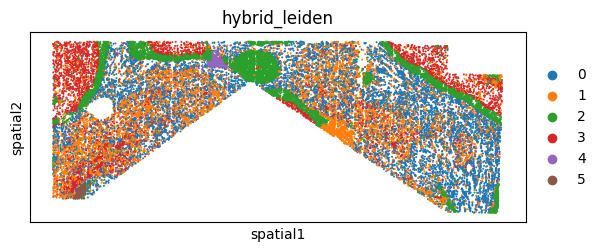

In [86]:
# PCA for transcriptomic representation
sc.pp.pca(adata_full_corr)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_full_corr, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_full_corr.obsm['generic'] = adata_full_corr.obsm['spatial']
sq.gr.spatial_neighbors(adata_full_corr, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_full_corr.obsp['connectivities']
spatial_graph = adata_full_corr.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.7  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_full_corr, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=0.7)

# --- Visualization ---
sc.pl.spatial(adata_full_corr, color=['hybrid_leiden'], spot_size=150)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


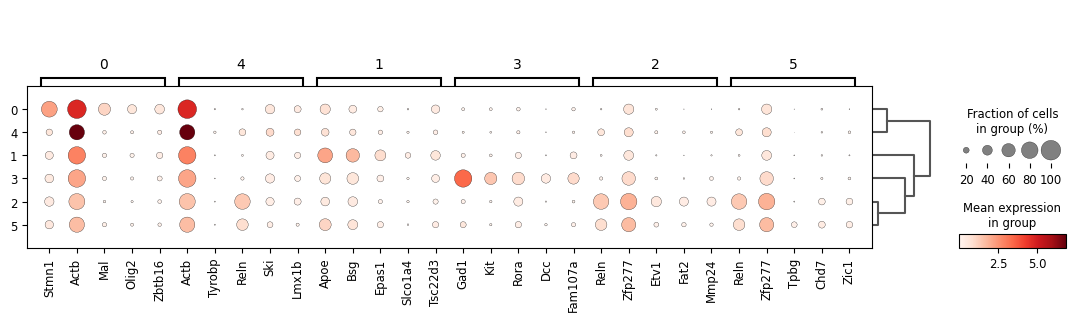

In [87]:
sc.tl.dendrogram(adata_full_corr, groupby="hybrid_leiden")
sc.tl.rank_genes_groups(adata_full_corr, 'hybrid_leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_full_corr, n_genes=5, key="wilcoxon", groupby="hybrid_leiden")

In [88]:
adata_crop_cn = adata_full_corr[adata_full_corr.obs['hybrid_leiden'].isin(['3','1'])]


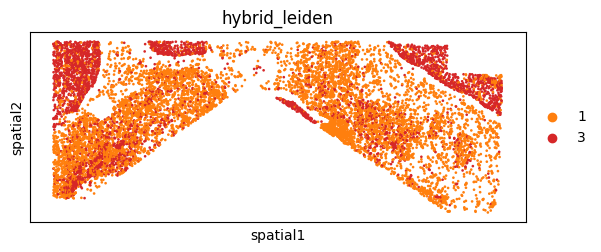

In [89]:
sc.pl.spatial(adata_crop_cn, color = "hybrid_leiden", spot_size = 200)

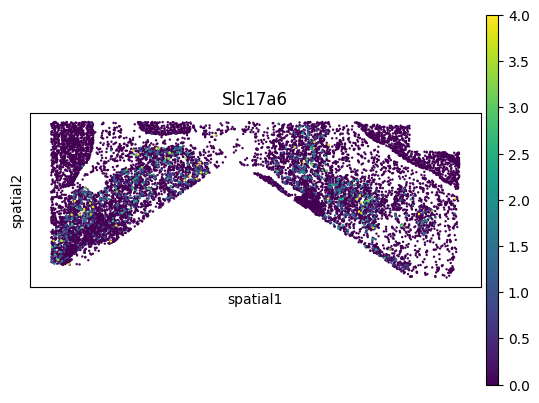

In [107]:
sc.pl.spatial(adata_crop_cn, color = "Slc17a6", spot_size = 200, vmax = 4)

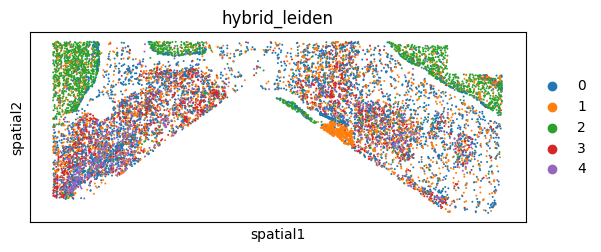

In [91]:
# PCA for transcriptomic representation
sc.pp.pca(adata_crop_cn)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_crop_cn, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_crop_cn.obsm['generic'] = adata_crop_cn.obsm['spatial']
sq.gr.spatial_neighbors(adata_crop_cn, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_crop_cn.obsp['connectivities']
spatial_graph = adata_crop_cn.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.7  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_crop_cn, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=0.5)

# --- Visualization ---
sc.pl.spatial(adata_crop_cn, color=['hybrid_leiden'], spot_size=150)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


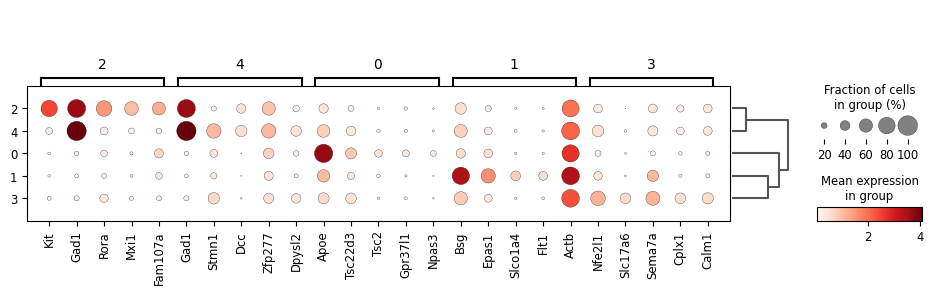

In [92]:
sc.tl.dendrogram(adata_crop_cn, groupby="hybrid_leiden")
sc.tl.rank_genes_groups(adata_crop_cn, 'hybrid_leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn, n_genes=5, key="wilcoxon", groupby="hybrid_leiden")

In [56]:
adata_crop_cn_sub = adata_crop_cn[adata_crop_cn.obs['hybrid_leiden'].isin(['4','3', '2'])]


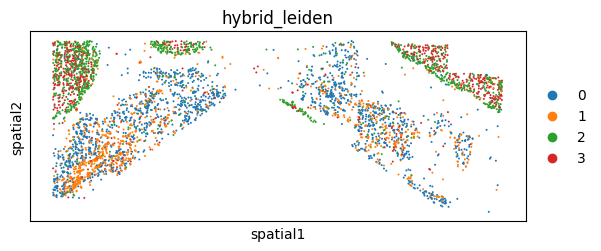

In [57]:
# PCA for transcriptomic representation
sc.pp.pca(adata_crop_cn_sub)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_crop_cn_sub, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_crop_cn_sub.obsm['generic'] = adata_crop_cn_sub.obsm['spatial']
sq.gr.spatial_neighbors(adata_crop_cn_sub, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_crop_cn_sub.obsp['connectivities']
spatial_graph = adata_crop_cn_sub.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.9  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_crop_cn_sub, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=0.7)

# --- Visualization ---
sc.pl.spatial(adata_crop_cn_sub, color=['hybrid_leiden'], spot_size=150)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


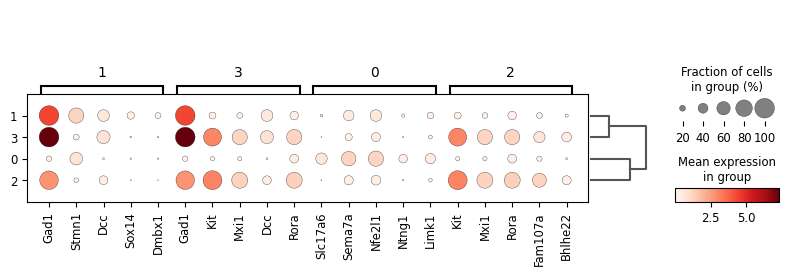

In [58]:
sc.tl.dendrogram(adata_crop_cn_sub, groupby="hybrid_leiden")
sc.tl.rank_genes_groups(adata_crop_cn_sub, 'hybrid_leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn_sub, n_genes=5, key="wilcoxon", groupby="hybrid_leiden")

In [59]:
adata_crop_cn_ct = adata_crop_cn_sub[adata_crop_cn_sub.obs['hybrid_leiden'].isin(['0', '1', '3'])]

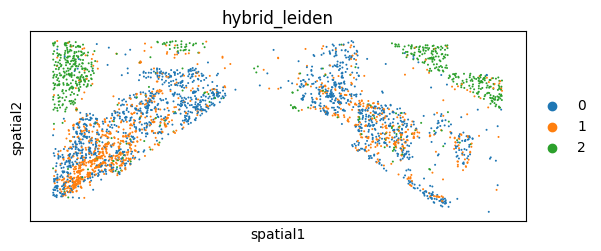

In [63]:
# PCA for transcriptomic representation
sc.pp.pca(adata_crop_cn_ct)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_crop_cn_ct, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_crop_cn_ct.obsm['generic'] = adata_crop_cn_ct.obsm['spatial']
sq.gr.spatial_neighbors(adata_crop_cn_ct, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_crop_cn_ct.obsp['connectivities']
spatial_graph = adata_crop_cn_ct.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.8  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_crop_cn_ct, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=0.5)

# --- Visualization ---
sc.pl.spatial(adata_crop_cn_ct, color=['hybrid_leiden'], spot_size=150)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


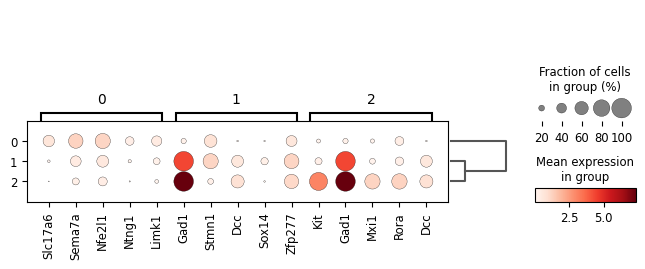

In [64]:
sc.tl.dendrogram(adata_crop_cn_ct, groupby="hybrid_leiden")
sc.tl.rank_genes_groups(adata_crop_cn_ct, 'hybrid_leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn_ct, n_genes=5, key="wilcoxon", groupby="hybrid_leiden")

In [65]:
adata_crop_cn_ct_sub = adata_crop_cn_ct[adata_crop_cn_ct.obs['hybrid_leiden'].isin(['1', '0'])]

In [66]:
import numpy as np

def gene_vec(adata, gene):
    x = adata[:, gene].X
    return np.asarray(x.toarray()).ravel() if hasattr(x, "toarray") else np.asarray(x).ravel()

sox14 = gene_vec(adata_crop_cn_ct_sub, "Sox14")
kit = gene_vec(adata_crop_cn_ct_sub, "Kit")
slc17a6 = gene_vec(adata_crop_cn_ct_sub, "Slc17a6")

# Start with NA
adata_crop_cn_ct_sub.obs["cell_type"] = np.nan

# Assign labels
adata_crop_cn_ct_sub.obs.loc[sox14 > 0, "cell_type"] = "i1 neurons"
adata_crop_cn_ct_sub.obs.loc[kit > 0, "cell_type"] = "i2/3 neurons"
adata_crop_cn_ct_sub.obs.loc[slc17a6 > 0, "cell_type"] = "Excitatory DCN"

adata_crop_cn_ct_sub = adata_crop_cn_ct_sub[
    adata_crop_cn_ct_sub.obs["cell_type"].notna()
].copy()

/var/folders/hl/knh17k4n5x56vbv9b64yxybc0000gn/T/ipykernel_33936/3909290393.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_crop_cn_ct_sub.obs["cell_type"] = np.nan


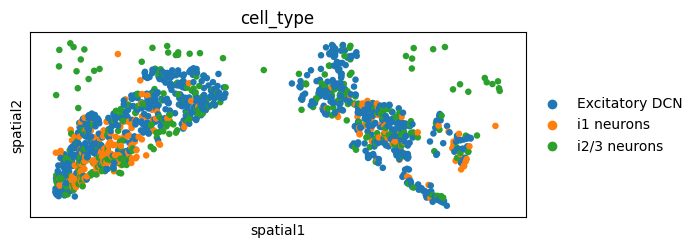

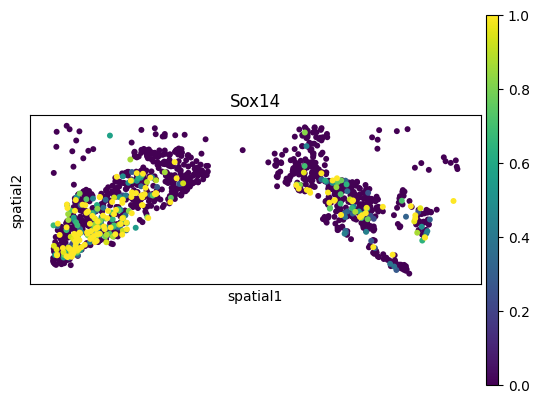

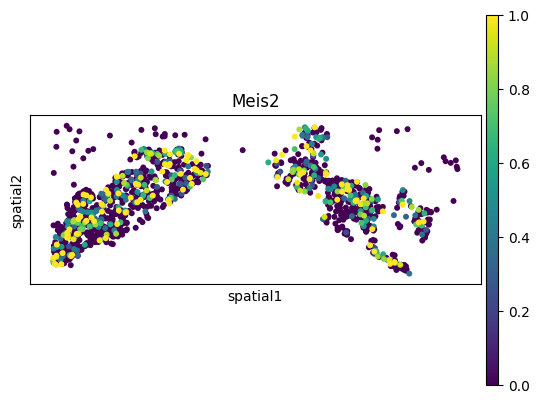

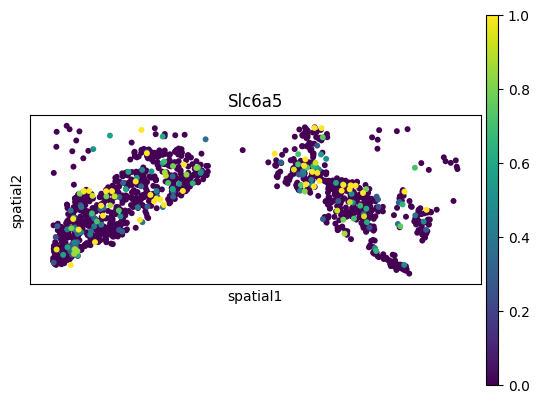

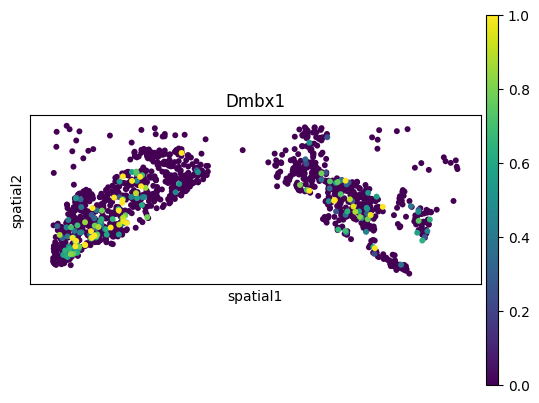

In [67]:
adata_crop_cn_ct_sub1 = adata_crop_cn_ct_sub.copy()
sc.pl.spatial(adata_crop_cn_ct_sub1, color=['cell_type'], spot_size=500)
sc.pl.spatial(adata_crop_cn_ct_sub1, color=['Sox14'], spot_size=500, vmax = 1)
sc.pl.spatial(adata_crop_cn_ct_sub1, color=['Meis2'], spot_size=500, vmax = 1)
sc.pl.spatial(adata_crop_cn_ct_sub1, color=['Slc6a5'], spot_size=500, vmax = 1)
sc.pl.spatial(adata_crop_cn_ct_sub1, color=['Dmbx1'], spot_size=500, vmax = 1)


In [74]:
adata_crop_cn_ct_sub = adata_crop_cn_ct[adata_crop_cn_ct.obs['hybrid_leiden'].isin(['1', '0'])]

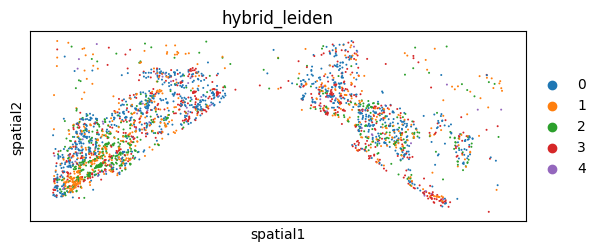

In [75]:
# PCA for transcriptomic representation
sc.pp.pca(adata_crop_cn_ct_sub)

# --- Compute expression-based neighbors ---
sc.pp.neighbors(adata_crop_cn_ct_sub, use_rep="X_pca", n_neighbors=10)  # adjustable

# --- Compute spatial neighbors ---
adata_crop_cn_ct_sub.obsm['generic'] = adata_crop_cn_ct_sub.obsm['spatial']
sq.gr.spatial_neighbors(adata_crop_cn_ct_sub, coord_type="generic", radius=150)  # tune radius to your tissue size

# --- Create hybrid adjacency: weighted sum ---
expr_graph = adata_crop_cn_ct_sub.obsp['connectivities']
spatial_graph = adata_crop_cn_ct_sub.obsp['spatial_connectivities']

# Weight expression vs spatial influence
alpha = 0.6  # higher = more transcriptomic, lower = more spatial
hybrid_graph = expr_graph.multiply(alpha) + spatial_graph.multiply(1 - alpha)

# --- Cluster using hybrid graph ---
sc.tl.leiden(adata_crop_cn_ct_sub, adjacency=hybrid_graph, key_added='hybrid_leiden', resolution=0.7)

# --- Visualization ---
sc.pl.spatial(adata_crop_cn_ct_sub, color=['hybrid_leiden'], spot_size=150)


/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


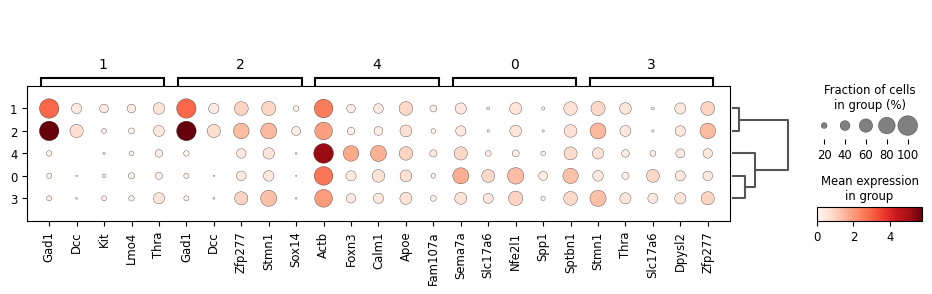

In [76]:
sc.tl.dendrogram(adata_crop_cn_ct_sub, groupby="hybrid_leiden")
sc.tl.rank_genes_groups(adata_crop_cn_ct_sub, 'hybrid_leiden', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn_ct_sub, n_genes=5, key="wilcoxon", groupby="hybrid_leiden")

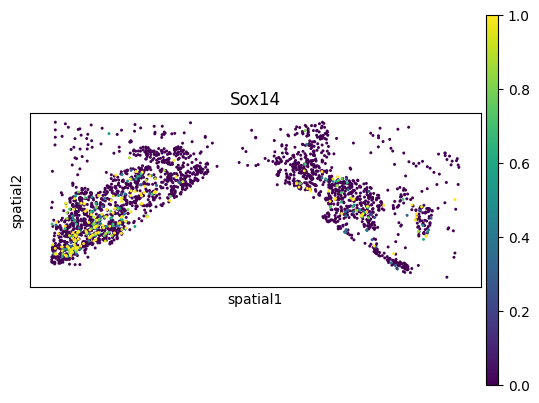

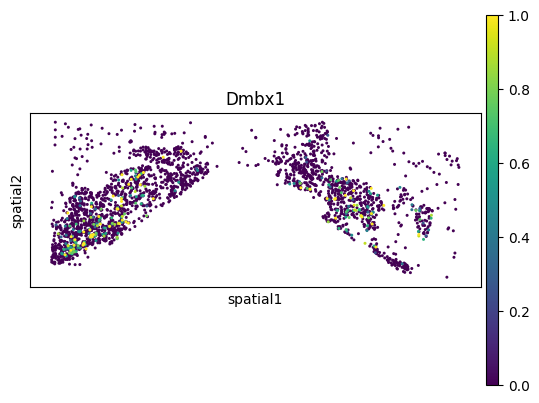

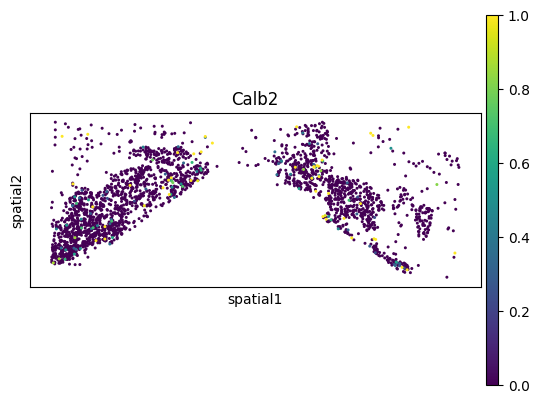

In [93]:
sc.pl.spatial(adata_crop_cn_ct_sub, color = "Sox14", spot_size = 250, vmax = 1)
sc.pl.spatial(adata_crop_cn_ct_sub, color = "Dmbx1", spot_size = 250, vmax = 1)
sc.pl.spatial(adata_crop_cn_ct_sub, color = "Calb2", spot_size = 250, vmax = 1)

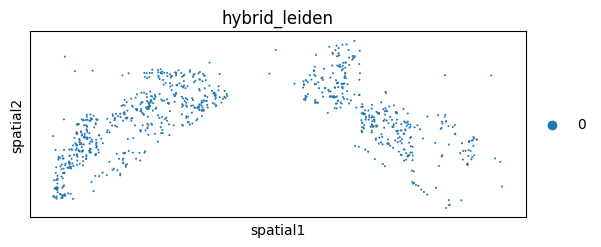

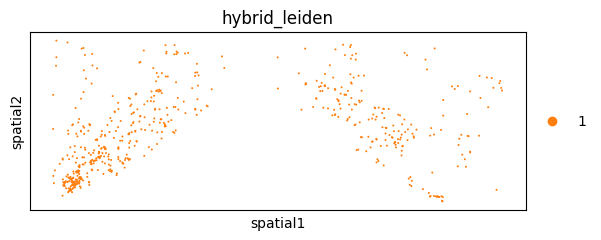

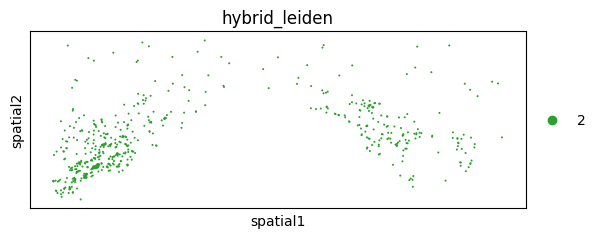

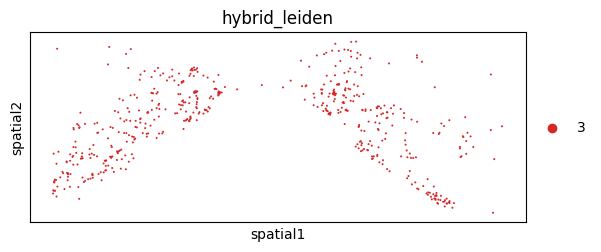

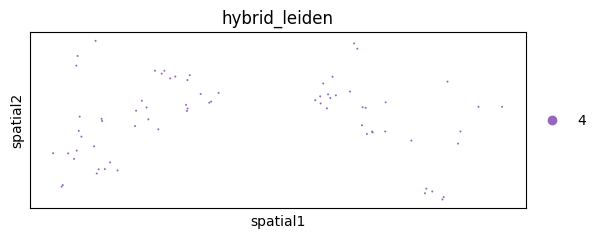

In [94]:
for i in np.unique(adata_crop_cn_ct_sub.obs['hybrid_leiden']):
    sc.pl.spatial(adata_crop_cn_ct_sub[adata_crop_cn_ct_sub.obs['hybrid_leiden'] == i], spot_size = 150, color = 'hybrid_leiden')
    

In [95]:
cluster_map = {
    "0": "Excitatory DCN",
    "3": "Excitatory DCN",
    "1": "i2/3 neurons",
    "2": "i1 neurons",
}

adata_crop_cn_ct_sub.obs["cell_type"] = (
    adata_crop_cn_ct_sub.obs["hybrid_leiden"]
    .astype(str)
    .map(cluster_map)
)

In [102]:
adata_crop_cn_ct_sub1 = adata_crop_cn_ct_sub[keep].copy()

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


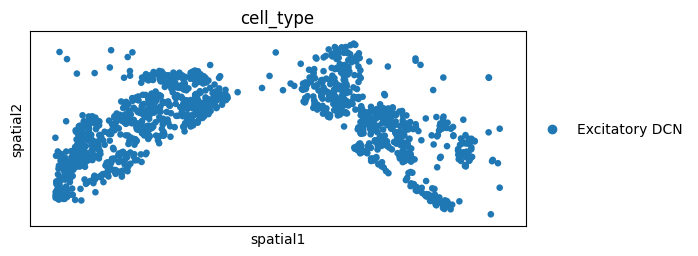

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


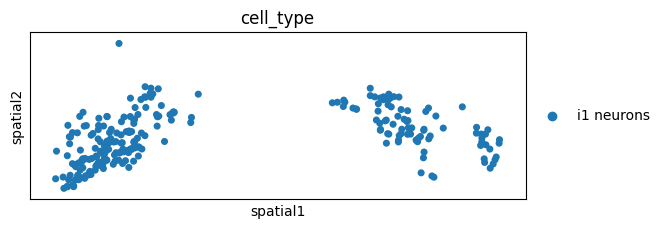

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


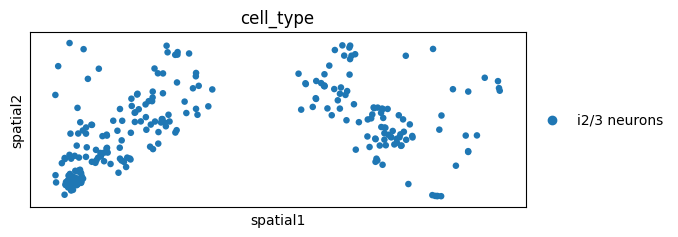

In [103]:
for i in np.unique(adata_crop_cn_ct_sub1.obs['cell_type']):
    sc.pl.spatial(adata_crop_cn_ct_sub1[adata_crop_cn_ct_sub1.obs['cell_type'] == i], spot_size = 500, color = 'cell_type')
    

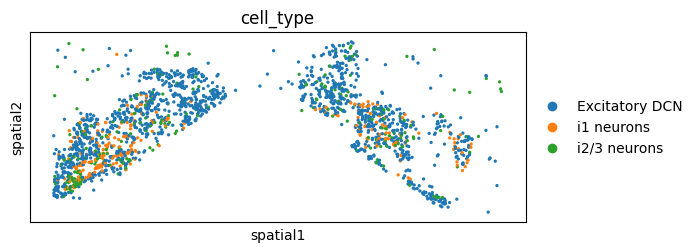

In [104]:
sc.pl.spatial(adata_crop_cn_ct_sub1, spot_size = 250, color = "cell_type")

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


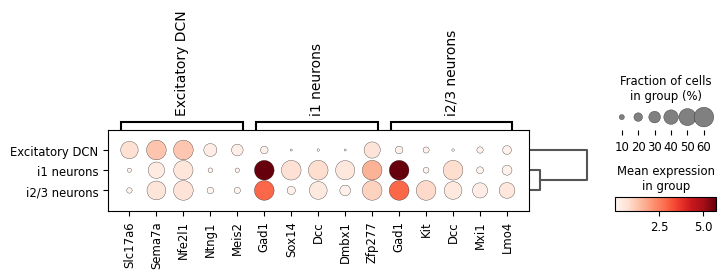

In [114]:
sc.tl.dendrogram(adata_crop_cn_ct_sub1, groupby="cell_type")
sc.tl.rank_genes_groups(adata_crop_cn_ct_sub1, 'cell_type', method='wilcoxon', key_added = "wilcoxon")
#sc.pl.rank_genes_groups_heatmap(adata,  n_genes=5, key="wilcoxon", groupby="leiden", show_gene_labels=True, vmax = 3)
sc.pl.rank_genes_groups_dotplot(adata_crop_cn_ct_sub1, n_genes=5, key="wilcoxon", groupby="cell_type", dot_max = 0.6, expression_cutoff = 0)

/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/Users/manjjj/miniforge3/envs/spatial_analysis/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


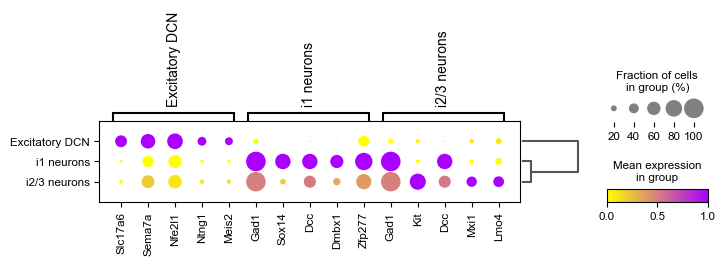

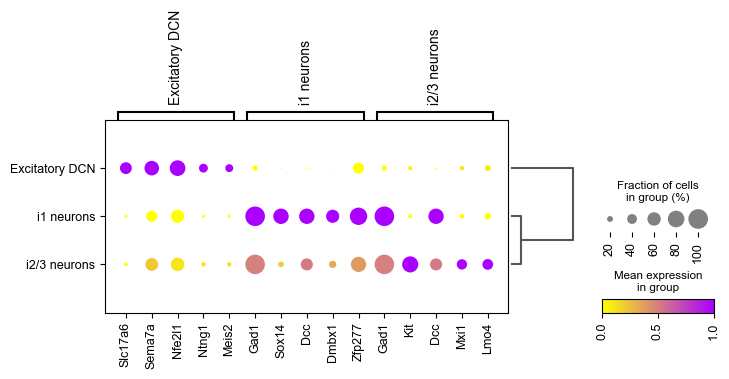

In [121]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# Arial throughout
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

# Seurat-like yellow → purple color scale
yellow_purple = LinearSegmentedColormap.from_list(
    "yellow_purple",
    ["yellow", "#AA00FF"]
)

dp = sc.pl.rank_genes_groups_dotplot(
    adata_crop_cn_ct_sub1,
    n_genes=5,
    key="wilcoxon",
    groupby="cell_type",
    dot_max=0.6,
    expression_cutoff=0,
    cmap=yellow_purple,
    standard_scale="var",   # scales each gene across cell types
    return_fig=True,
    show=False,
)

dp.style(
    cmap=yellow_purple,
    dot_edge_color="black",
    dot_edge_lw=0,
    largest_dot=200,
)

dp.make_figure()

dp.savefig(
    "adult_cb_fig.svg",
    bbox_inches="tight"
)
# Format all axes
for ax in dp.get_axes().values():
    for label in ax.get_xticklabels():
        label.set_fontname("Arial")
        label.set_fontsize(9)
        label.set_rotation(90)

    for label in ax.get_yticklabels():
        label.set_fontname("Arial")
        label.set_fontsize(9)

    ax.set_xlabel(ax.get_xlabel(), fontname="Arial")
    ax.set_ylabel(ax.get_ylabel(), fontname="Arial")

plt.show()

In [293]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "Arial",
    "svg.fonttype": "none",  # editable text in Illustrator
    "pdf.fonttype": 42,
})

sc.pl.spatial(
    adata_all,
    color="cell_type",
    spot_size=350,
    show=False
)

plt.savefig(
    "adata_all_cell_type_spatial.png",
    bbox_inches="tight"
)

plt.close()

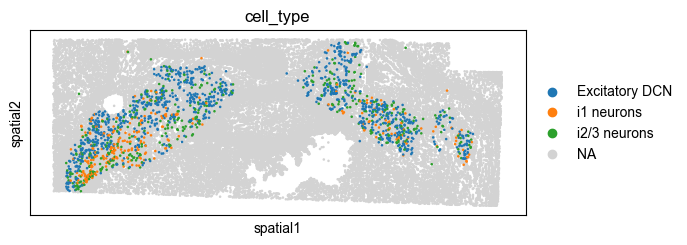

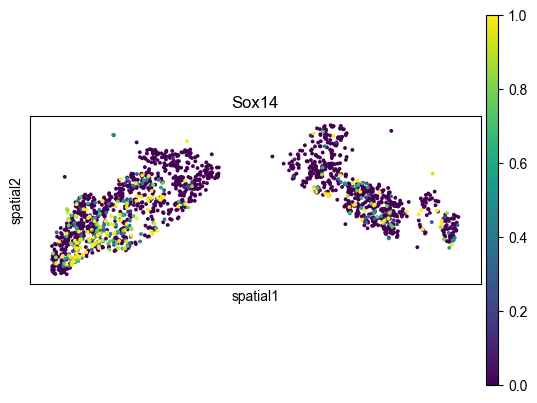

In [176]:

sc.pl.spatial(adata_all, color = 'cell_type', spot_size = 200)
sc.pl.spatial(adata_crop_cn_ct_sub1, color = 'Sox14', spot_size = 300, vmax = 1)


In [288]:
import scanpy as sc
import matplotlib.pyplot as plt

# background
sc.pl.spatial(
    adata_all,
    color=None,
    spot_size=200,
    show=False
)

ax = plt.gca()

# overlay only one cell type
sc.pl.spatial(
    adata_all,
    color="cell_type",
    groups=["Excitatory DCN"],
    spot_size=350,
    na_color="none",
    ax=ax,
    show=False
)

plt.savefig(
    "Excitatory_DCN_overlay.png",
    bbox_inches="tight"
)
plt.close()

In [289]:
import scanpy as sc
import matplotlib.pyplot as plt

# background
sc.pl.spatial(
    adata_all,
    color=None,
    spot_size=200,
    show=False
)

ax = plt.gca()

# overlay only one cell type
sc.pl.spatial(
    adata_all,
    color="cell_type",
    groups=["i1 neurons"],
    spot_size=350,
    na_color="none",
    ax=ax,
    show=False
)

plt.savefig(
    "i1_DCN_overlay.png",
    bbox_inches="tight"
)
plt.close()

In [290]:
import scanpy as sc
import matplotlib.pyplot as plt

# background
sc.pl.spatial(
    adata_all,
    color=None,
    spot_size=200,
    show=False
)

ax = plt.gca()

# overlay only one cell type
sc.pl.spatial(
    adata_all,
    color="cell_type",
    groups=["i2/3 neurons"],
    spot_size=350,
    na_color="none",
    ax=ax,
    show=False
)

plt.savefig(
    "i2-3_DCN_overlay.png",
    bbox_inches="tight"
)
plt.close()

In [73]:
#Based on manual counting from drawing CN subnuclei boundaries
i1 = {
    "Med/MedDL": [1, 0],
    "MedL": [6, 8],
    "Int": [30, 23],
    "Lat": [24, 10]
}

i23 = {
    "Med/MedDL": [12, 10],
    "MedL": [12, 14],
    "Int": [21, 25],
    "Lat": [32, 12]
}

exc = {
    "Med/MedDL": [39, 27],
    "MedL": [25, 18],
    "Int": [56, 43],
    "Lat": [57, 13]
}


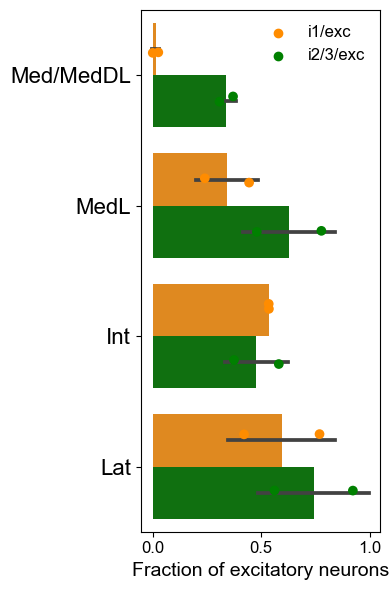

In [315]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Use Arial if installed
mpl.rcParams["font.family"] = "Arial"
rows = []

for region in i1:
    for rep in range(2):

        rows.append({
            "Region": region,
            "Ratio": "i1/exc",
            "Value": i1[region][rep] / exc[region][rep]
        })

        rows.append({
            "Region": region,
            "Ratio": "i2/3/exc",
            "Value": i23[region][rep] / exc[region][rep]
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(4,6))

ax = sns.barplot(
    data=df,
    y="Region",
    x="Value",
    hue="Ratio",
    errorbar="sd",
    palette={
        "i1/exc": "darkorange",
        "i2/3/exc": "green"
    }
)

sns.stripplot(
    data=df,
    y="Region",
    x="Value",
    hue="Ratio",
    dodge=True,
    palette={
        "i1/exc": "darkorange",
        "i2/3/exc": "green"
    },
    size=7,
    ax=ax
)

# remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2],
    labels[:2],
    frameon=False,
    prop={"size": 12}
)

ax.set_xlabel("Fraction of excitatory neurons", fontsize=14)
ax.set_ylabel("")

# Increase nuclei label size
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()

plt.savefig(
    "cn_ratios.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()